# ERICA end-to-end test at K=4 — VDX 3-gene and VDX full

Companion notebook for `e2e_test.py`. Same canonical pipeline at fixed K=4 on:

1. **VDX 3-gene subset** (344 samples × 3 genes) — fast, runs in seconds.
2. **VDX full** (344 samples × 22 283 genes) — needs `data/vdx_full.npz`; see [`README_vdx_full.md`](README_vdx_full.md) for the one-shot conversion.

Plot ordering: MATLAB-recap figures first (`plot_assignment_scatter`, `plot_assignment_heatmap`), then enriched library figures (`plot_pcsp`, `plot_icah`, CLAM heatmap, cluster sizes, stability strips).

**Prerequisite:** `pip install erica` (>= 0.2.4) — installs all plotting deps.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from erica import (
    ERICA,
    set_publication_style,
    plot_assignment_scatter,
    plot_assignment_heatmap,
    plot_pcsp,
    plot_icah,
    plot_clam_heatmap_mpl,
    plot_cluster_sizes_mpl,
    plot_stability_strips,
)

set_publication_style()
%matplotlib inline

K = 4
METHODS = ['kmeans', 'agglomerative_ward']

## 1. VDX 3-gene

Tiny 3-gene subset distributed in the repo. Use it to sanity-check the
pipeline before running the full microarray.

In [2]:
X3 = pd.read_csv(os.path.join('..', 'examples', 'data', 'VDX_3_SV.csv'),
                 header=None).to_numpy()
print('VDX 3-gene shape:', X3.shape)

er3 = ERICA(
    data=X3,
    k_range=[K],
    n_iterations=50,
    method=METHODS,
    transpose=False,
    random_state=42,
    verbose=False,
)
results3 = er3.run()
for m in METHODS:
    metrics = results3['metrics'][K][m]
    print(f"  {m:22s}  CRI={metrics['CRI']:.3f}  WCRI={metrics['WCRI']:.3f}  TWCRI={metrics['TWCRI']:.3f}")

VDX 3-gene shape: (344, 3)

=== Cluster Index Summary ===
CRI: 0.899662

CRI_per_cluster: [0.9787508695924538, 0.7931354842773527, 0.9430344478216819, 0.8837274028450498]
WCRI: 0.224336

WCRI_per_cluster: [0.28736580764197045, 0.1959782446615552, 0.12884482281284607, 0.2851562259180248]
TWCRI: 0.897345

cluster_sizes: [101, 85, 47, 111]
k: 4
has_empty_clusters: False


=== Cluster Index Summary ===
CRI: 0.767618

CRI_per_cluster: [0.8880763680763679, 0.7207071922367656, 0.8925738791123404, 0.5691153049848702]
WCRI: 0.194678

WCRI_per_cluster: [0.2581617349059209, 0.38130438659038185, 0.10119296885285255, 0.038051313996081436]
TWCRI: 0.778710

cluster_sizes: [100, 182, 39, 23]
k: 4
has_empty_clusters: False

  kmeans                  CRI=0.900  WCRI=0.224  TWCRI=0.897
  agglomerative_ward      CRI=0.768  WCRI=0.195  TWCRI=0.779


### MATLAB-recap figures — VDX 3-gene

Two plots that recapitulate the original `clam_matrix_sort_18a.m`
MATLAB script: percent-scale 1×K assignment scatter and the K×K
cross-assignment heatmap. K-Means only here for brevity.

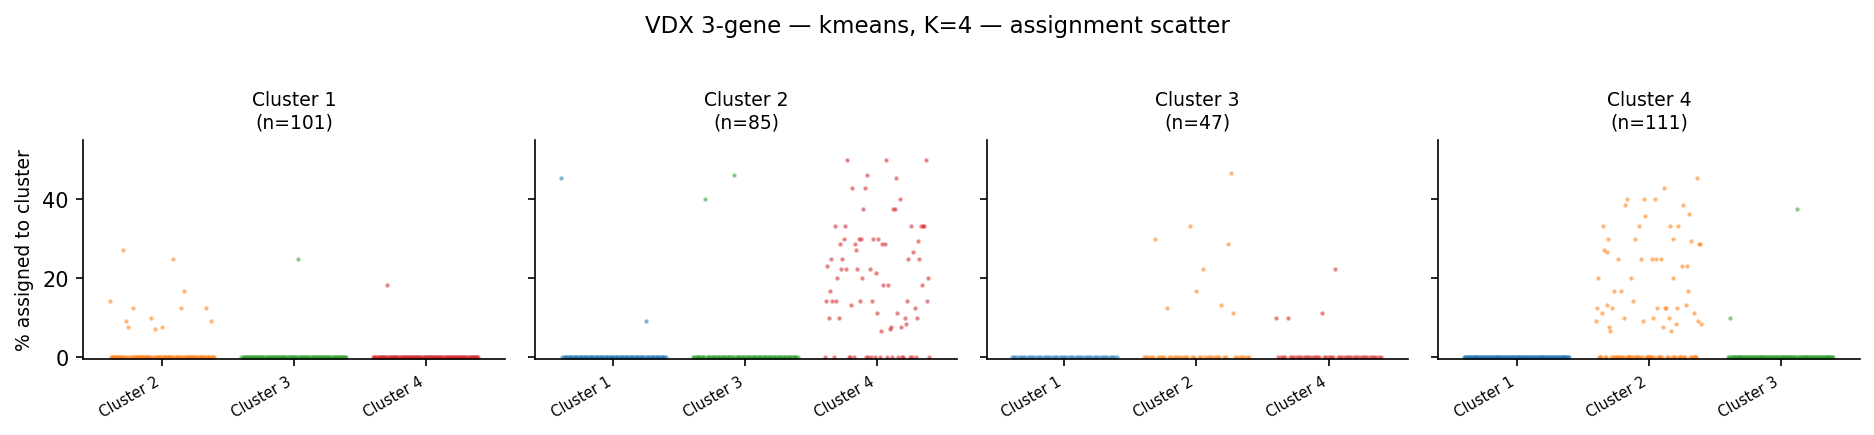

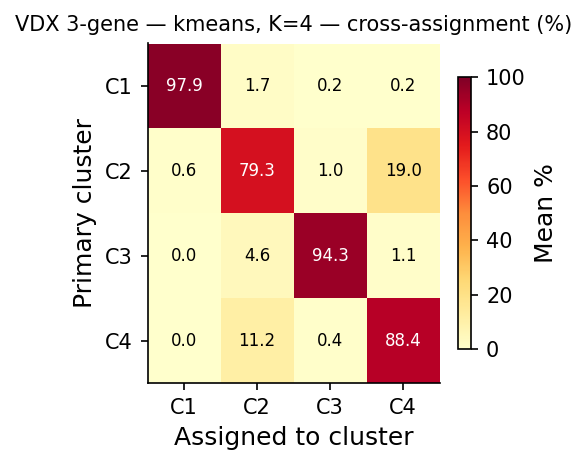

In [3]:
method = 'kmeans'
clam3 = results3['clam_matrices'][(K, method)]

fig = plot_assignment_scatter(clam3, method=method, k=K,
                              title=f'VDX 3-gene — {method}, K={K} — assignment scatter')
plt.show()

fig, _ = plot_assignment_heatmap(clam3, k=K,
                                 title=f'VDX 3-gene — {method}, K={K} — cross-assignment (%)')
plt.show()

### Enriched library figures — VDX 3-gene

PCSP (image-style with U-notation annotations), ICAH (proportion heatmap),
CLAM heatmap, cluster sizes, stability strips.

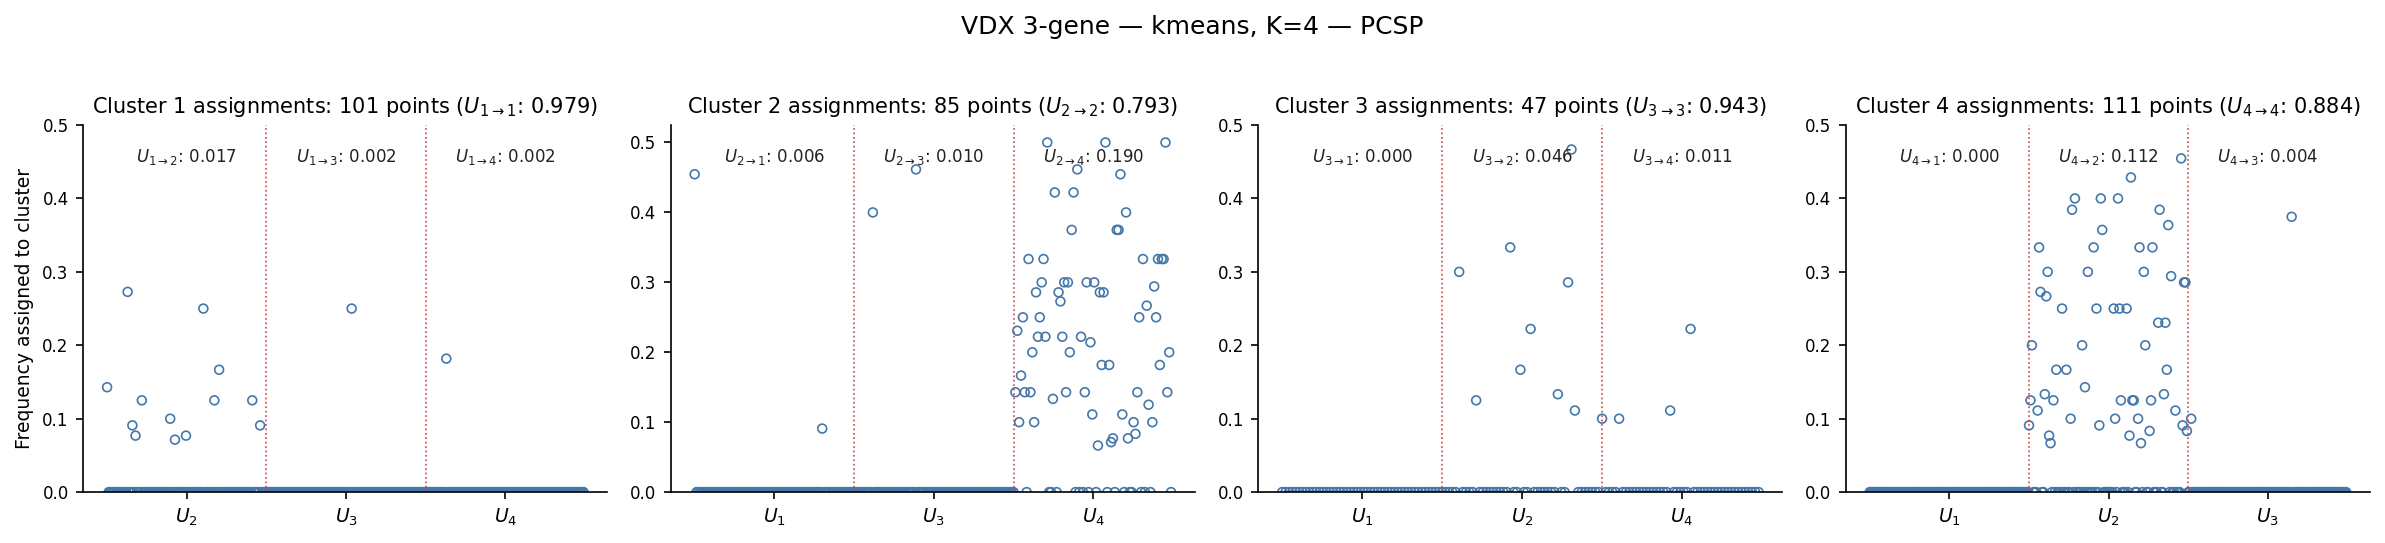

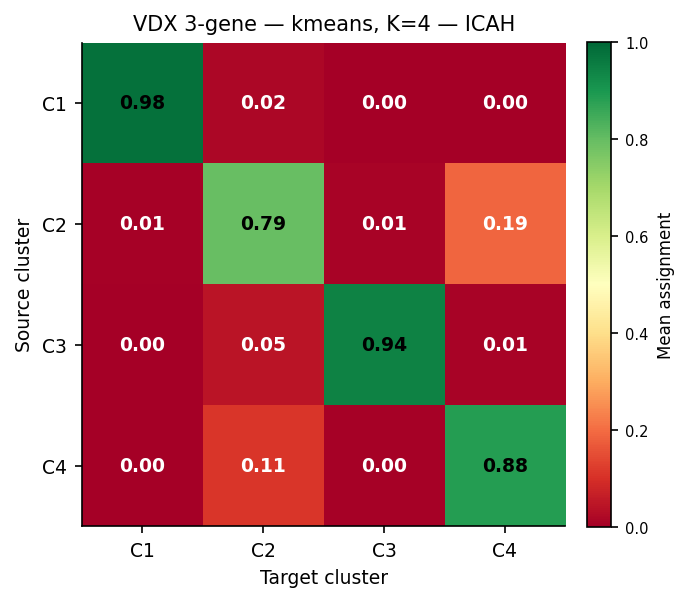

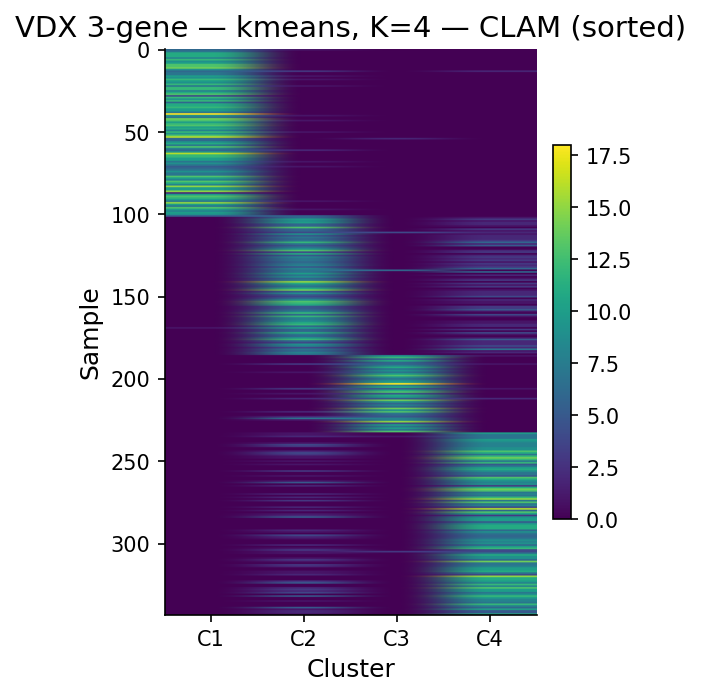

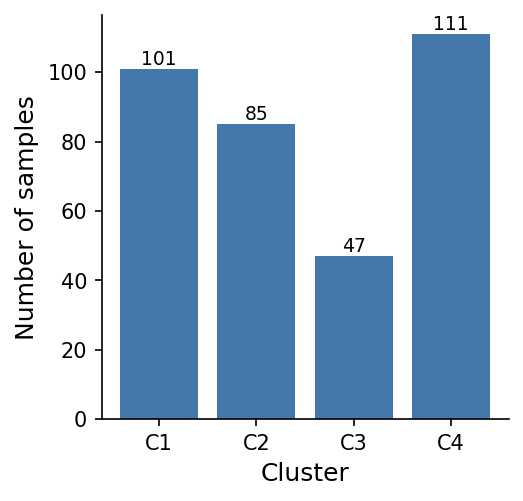

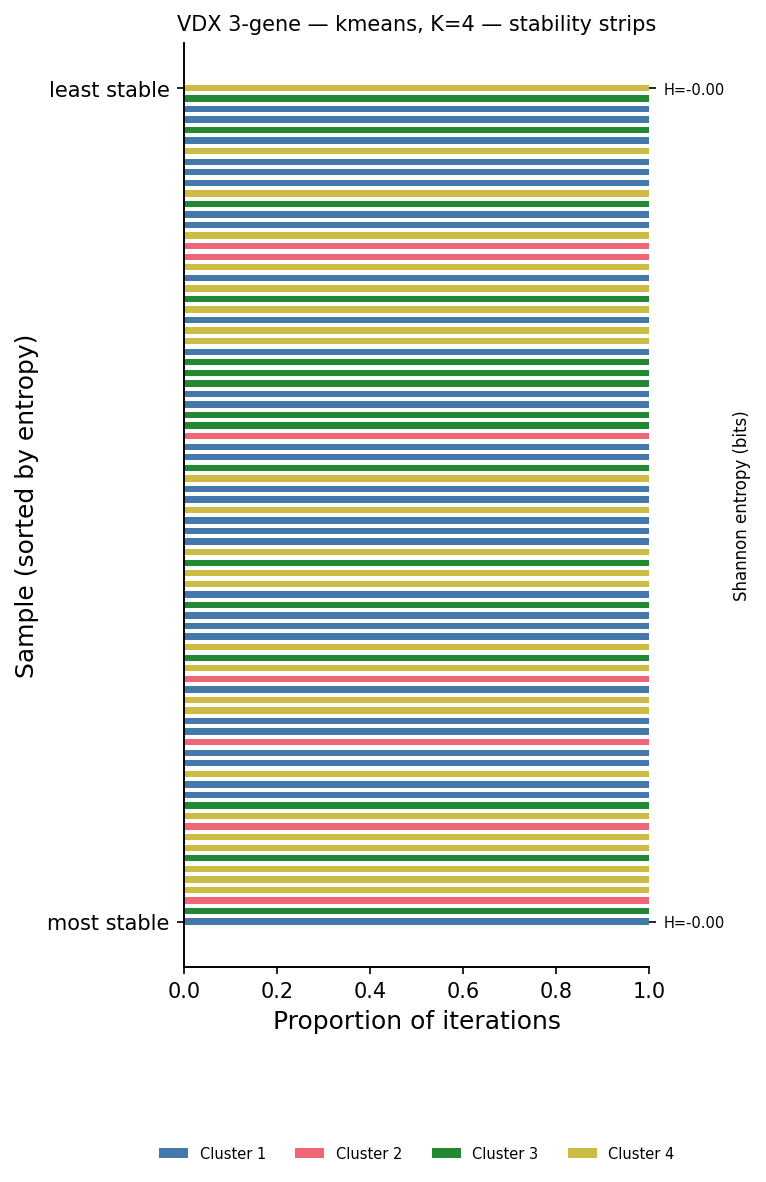

In [4]:
fig = plot_pcsp(clam3, k=K, title=f'VDX 3-gene — {method}, K={K} — PCSP')
plt.show()

fig, _ = plot_icah(clam3, k=K, title=f'VDX 3-gene — {method}, K={K} — ICAH')
plt.show()

fig, _ = plot_clam_heatmap_mpl(clam3, sort=True,
                                title=f'VDX 3-gene — {method}, K={K} — CLAM (sorted)')
plt.show()

fig, _ = plot_cluster_sizes_mpl(clam3)
plt.show()

fig, _ = plot_stability_strips(clam3, max_samples=80,
                                title=f'VDX 3-gene — {method}, K={K} — stability strips')
plt.show()

## 2. VDX full (344 × 22 283)

Loads from the safe `vdx_full.npz` cache. If you don't have it yet,
see [`README_vdx_full.md`](README_vdx_full.md) for the one-shot
download + convert command.

In [5]:
VDX_FULL_NPZ = os.path.join('data', 'vdx_full.npz')

if not os.path.exists(VDX_FULL_NPZ):
    raise FileNotFoundError(
        f'Missing {VDX_FULL_NPZ}. See README_vdx_full.md for setup.'
    )

Xf = np.load(VDX_FULL_NPZ)['X_all']
print('VDX full shape:', Xf.shape)

erf = ERICA(
    data=Xf,
    k_range=[K],
    n_iterations=30,
    method=METHODS,
    transpose=False,
    random_state=42,
    verbose=False,
)
resultsf = erf.run()
for m in METHODS:
    metrics = resultsf['metrics'][K][m]
    print(f"  {m:22s}  CRI={metrics['CRI']:.3f}  WCRI={metrics['WCRI']:.3f}  TWCRI={metrics['TWCRI']:.3f}")

VDX full shape: (344, 22283)

=== Cluster Index Summary ===
CRI: 0.551446

CRI_per_cluster: [0.4973470123980328, 0.5508463541666666, 0.5674925951241739, 0.590098261526833]
WCRI: 0.136019

WCRI_per_cluster: [0.1416860674854861, 0.2049660852713178, 0.12537627101580587, 0.072046880767811]
TWCRI: 0.544075

cluster_sizes: [98, 128, 76, 42]
k: 4
has_empty_clusters: False


=== Cluster Index Summary ===
CRI: 0.714120

CRI_per_cluster: [0.6429029047084603, 0.7672859547859547, 0.69989783329478, 0.7463924963924965]
WCRI: 0.175233

WCRI_per_cluster: [0.20184160961777242, 0.1739776292828618, 0.2665308609349307, 0.05858313198429478]
TWCRI: 0.700933

cluster_sizes: [108, 78, 131, 27]
k: 4
has_empty_clusters: False

  kmeans                  CRI=0.551  WCRI=0.136  TWCRI=0.544
  agglomerative_ward      CRI=0.714  WCRI=0.175  TWCRI=0.701


### MATLAB-recap figures — VDX full

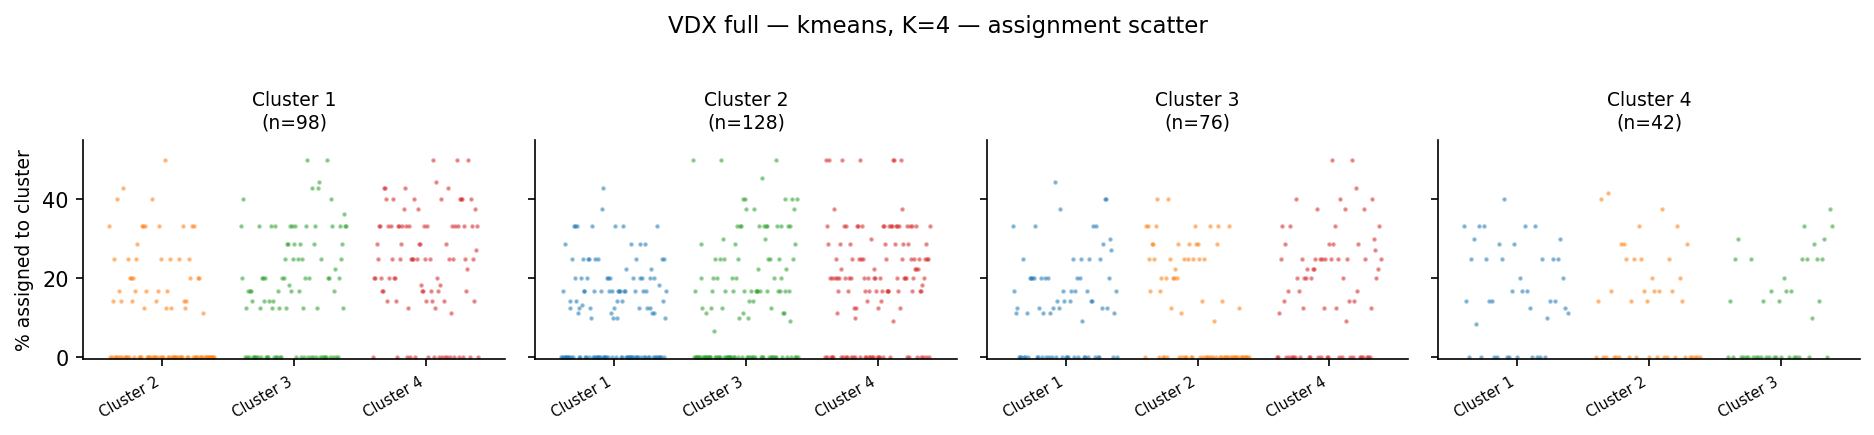

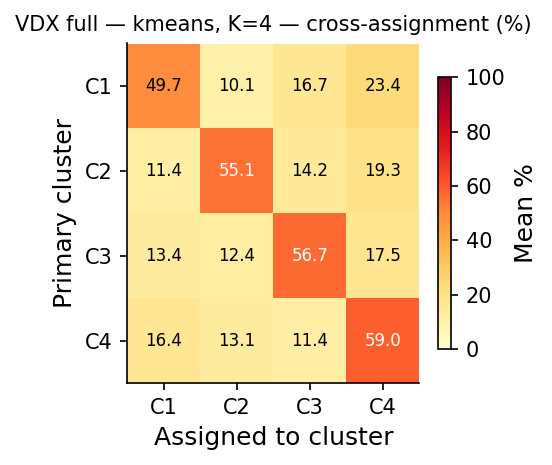

In [6]:
clamf = resultsf['clam_matrices'][(K, method)]

fig = plot_assignment_scatter(clamf, method=method, k=K,
                              title=f'VDX full — {method}, K={K} — assignment scatter')
plt.show()

fig, _ = plot_assignment_heatmap(clamf, k=K,
                                 title=f'VDX full — {method}, K={K} — cross-assignment (%)')
plt.show()

### Enriched library figures — VDX full

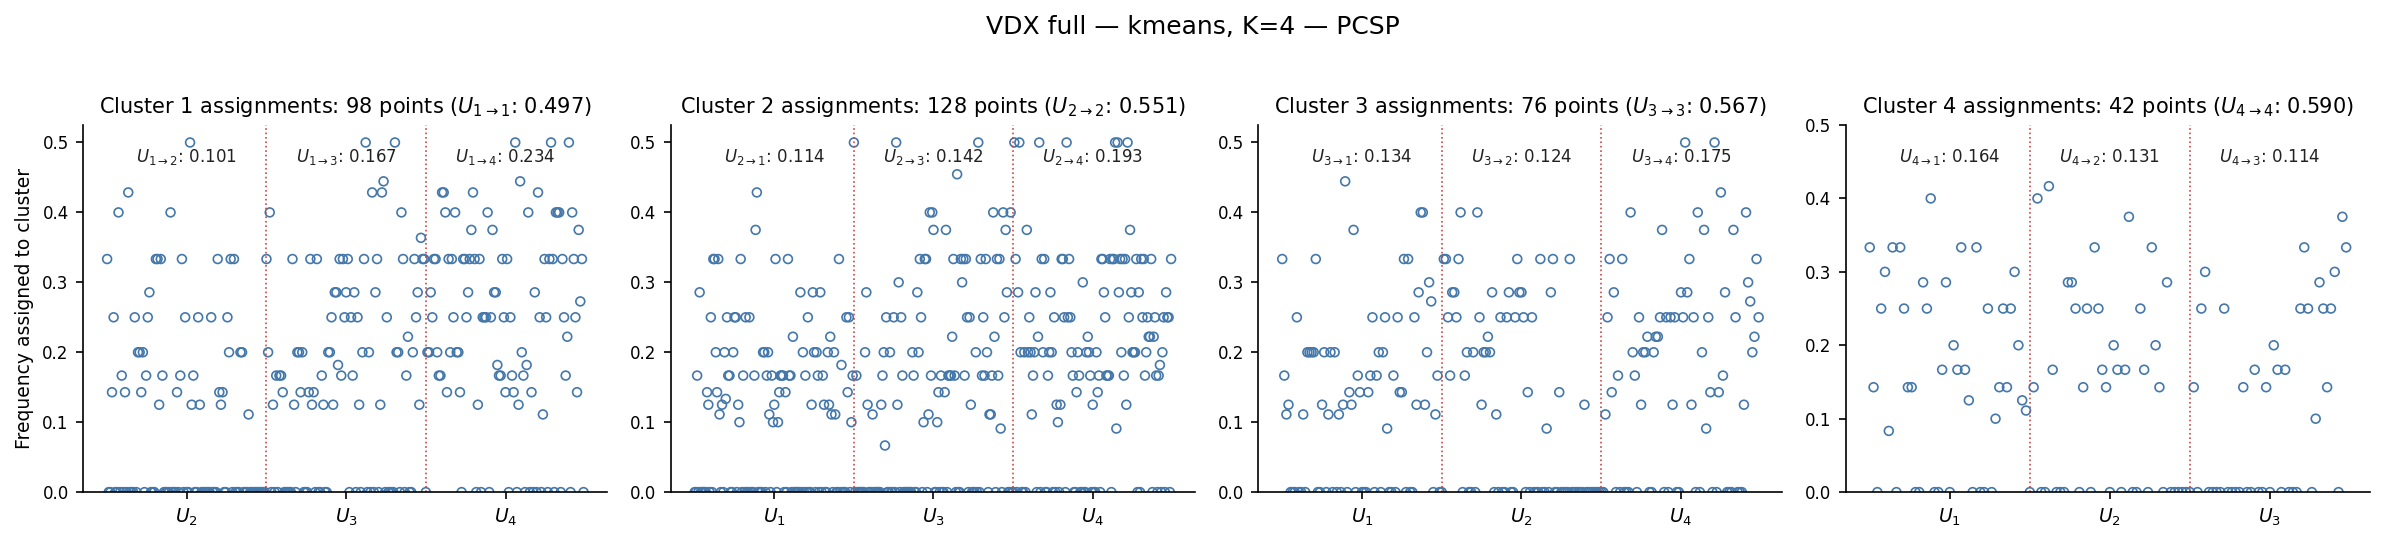

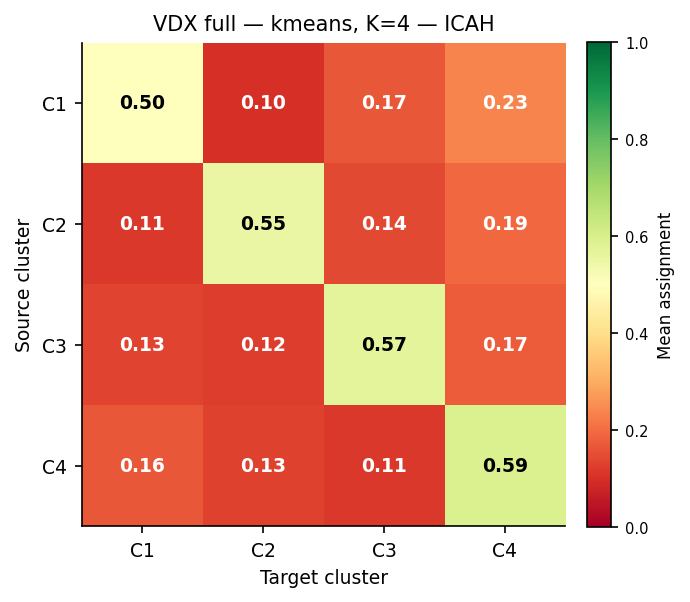

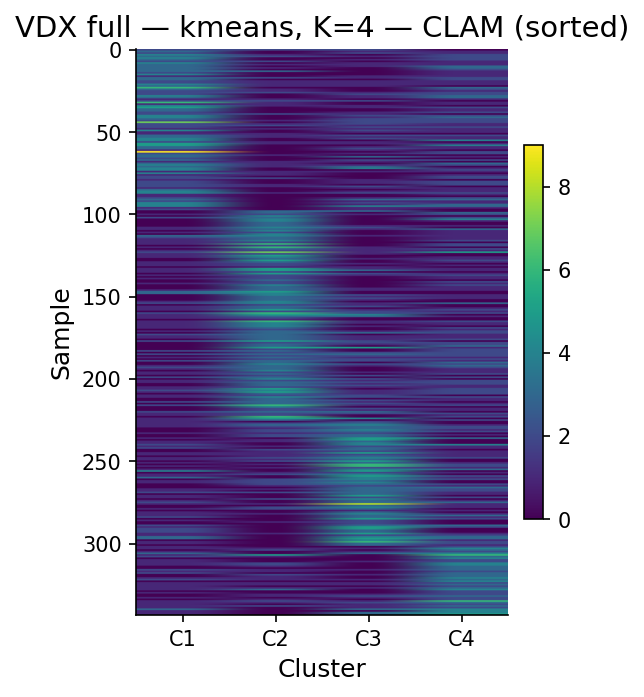

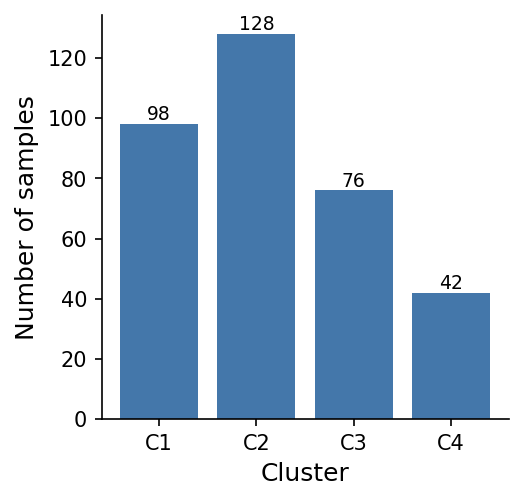

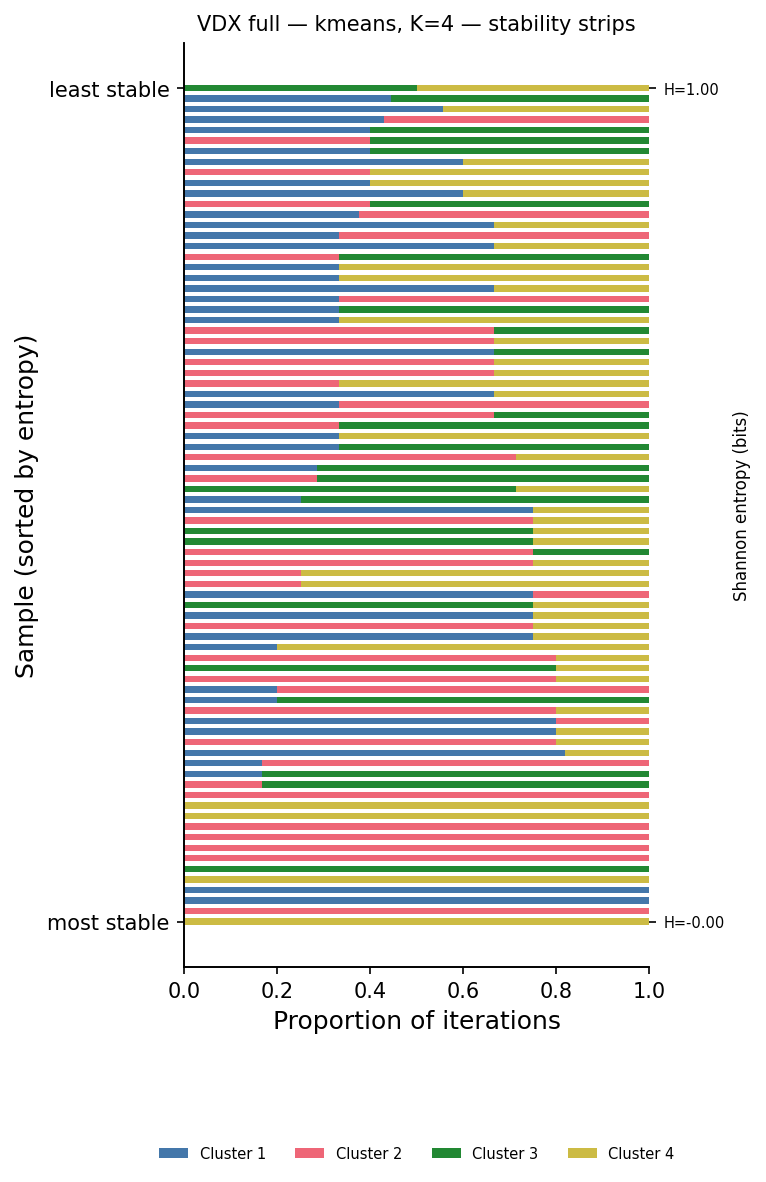

In [7]:
fig = plot_pcsp(clamf, k=K, title=f'VDX full — {method}, K={K} — PCSP')
plt.show()

fig, _ = plot_icah(clamf, k=K, title=f'VDX full — {method}, K={K} — ICAH')
plt.show()

fig, _ = plot_clam_heatmap_mpl(clamf, sort=True,
                                title=f'VDX full — {method}, K={K} — CLAM (sorted)')
plt.show()

fig, _ = plot_cluster_sizes_mpl(clamf)
plt.show()

fig, _ = plot_stability_strips(clamf, max_samples=80,
                                title=f'VDX full — {method}, K={K} — stability strips')
plt.show()

## Recap

Same library, same plots, two scales of input — 3 genes vs 22 283 genes.
Use `er.run(...)` once, then any of the plotters takes the resulting
CLAM matrix as a single argument.

Saved CLAMs from the matching script (`e2e_test.py`) live under
`figures/e2e_test/<dataset>/clams/clam_<method>_K4.npz` and can be
loaded with `np.load(...)['clam']` to reproduce any of these plots
without re-running ERICA.